In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.tree import plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
diabetes = load_diabetes()
df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
df['target'] = diabetes.target

In [3]:
df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.268604e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


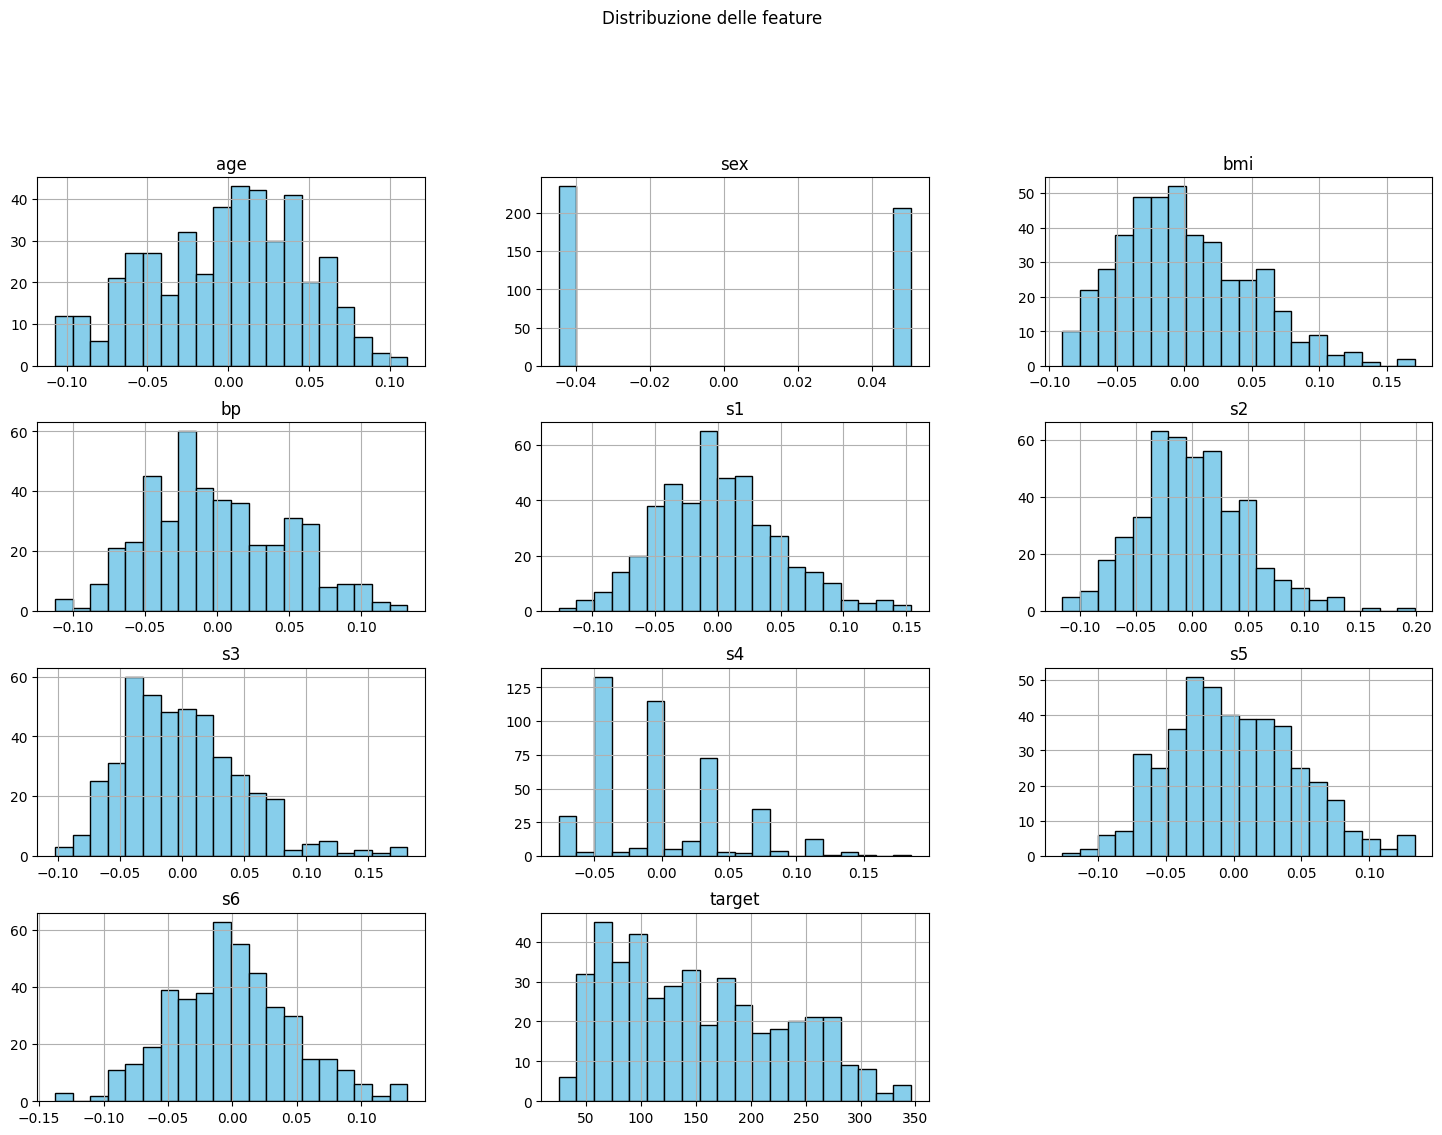

In [4]:
df.hist(bins=20, figsize=(18,12), color='skyblue', edgecolor='black')
plt.suptitle("Distribuzione delle feature", y=1.02)
plt.show()

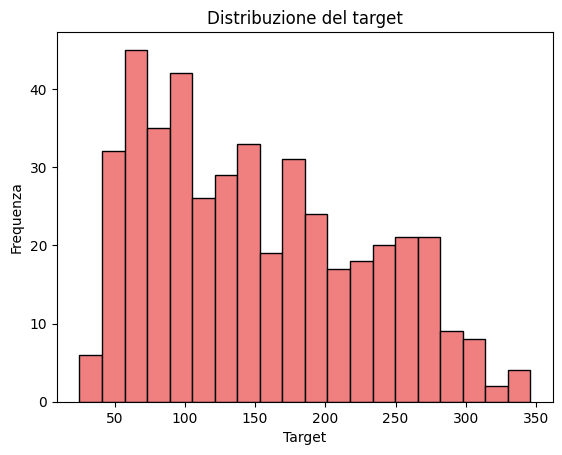

In [5]:
plt.hist(df['target'], bins=20, color='lightcoral', edgecolor='black')
plt.title("Distribuzione del target")
plt.xlabel("Target")
plt.ylabel("Frequenza")
plt.show()

In [6]:
features = ['bmi', 'bp']
X = df[features].values
y = df['target'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
model = RandomForestRegressor(random_state=42, n_estimators=100, max_depth=4)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [8]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.2f}")
print(f"R²: {r2:.2f}")

MSE: 4008.17
R²: 0.24


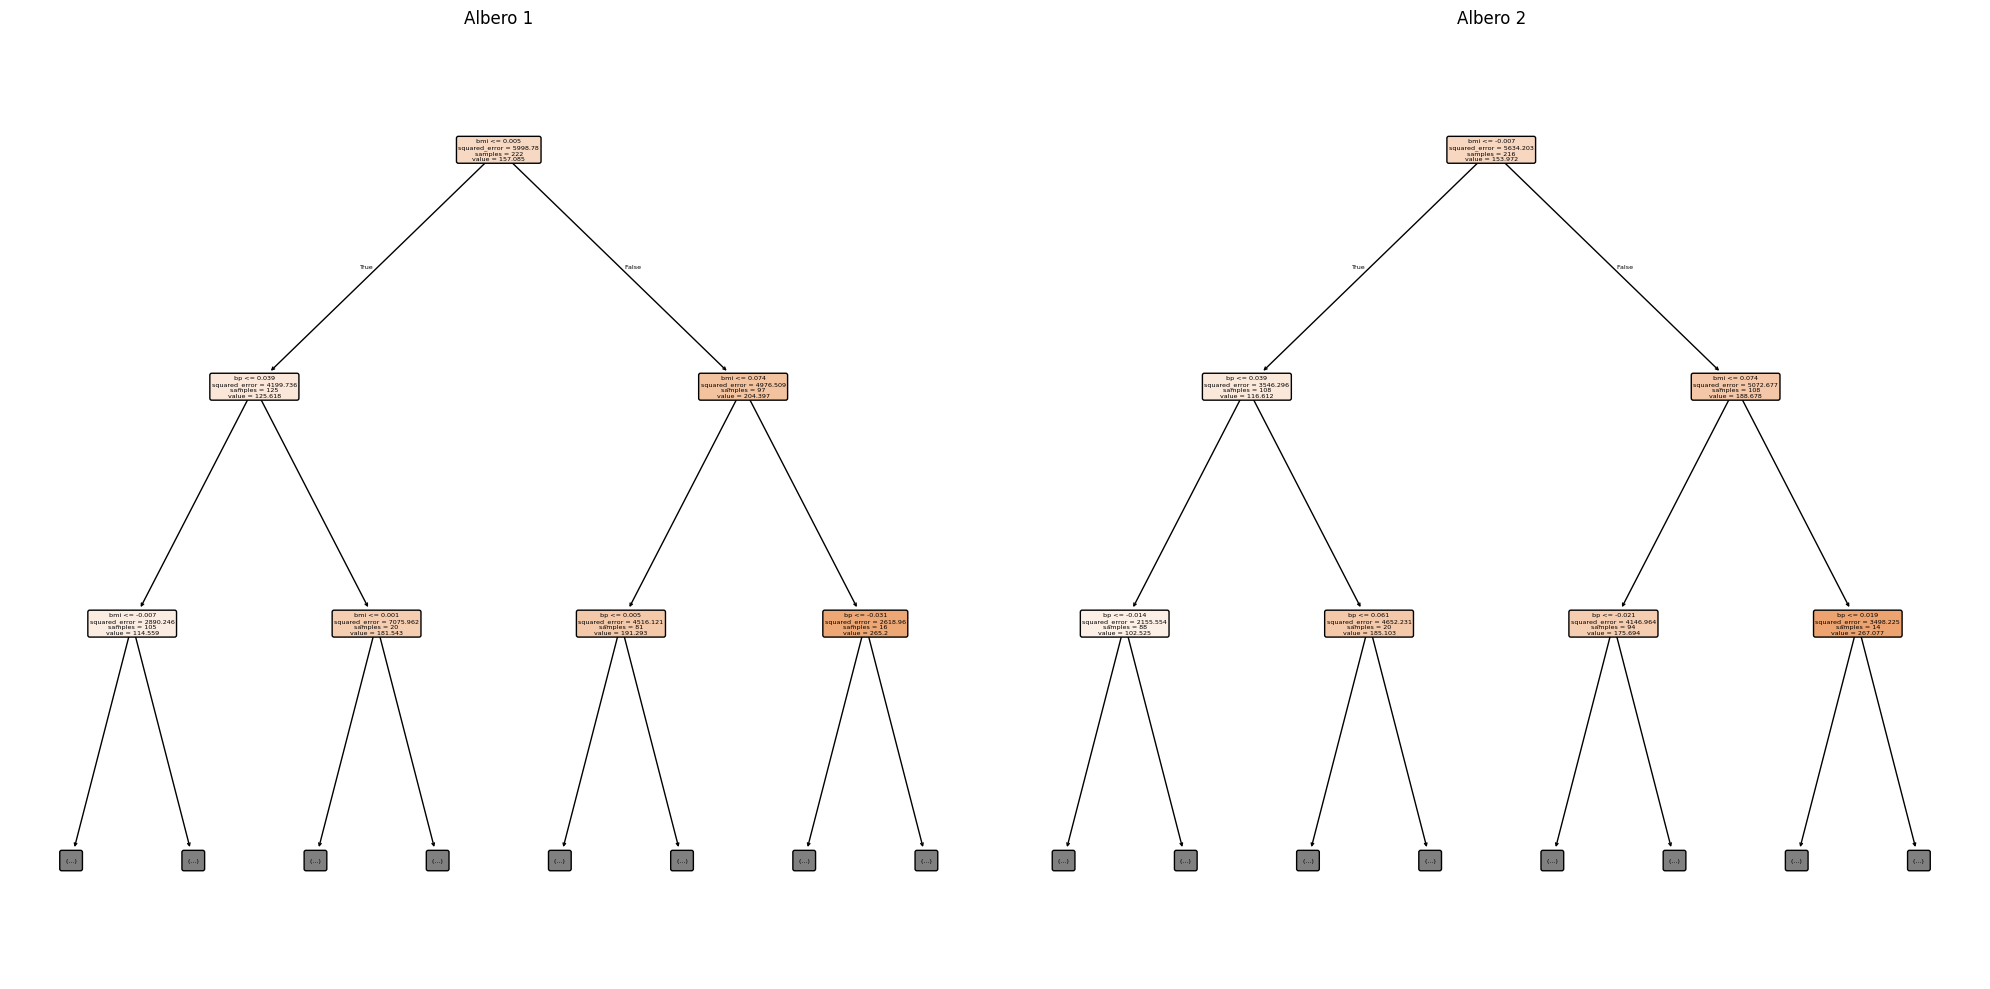

In [9]:
n_trees = 2

plt.figure(figsize=(20, 10))

for i in range(n_trees):
    plt.subplot(1, n_trees, i + 1)
    plot_tree(
        model.estimators_[i],
        feature_names=features,
        filled=True,
        rounded=True,
        max_depth=2
    )
    plt.title(f"Albero {i+1}")

plt.tight_layout()
plt.show()

In [10]:
features_best = diabetes.feature_names
X_best = df[features_best].values

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_best, y, test_size=0.2, random_state=42)

In [11]:
model_best = RandomForestRegressor(random_state=42, n_estimators=100, max_depth=6)
model_best.fit(X_train_b, y_train_b)
y_pred_best = model_best.predict(X_test_b)

In [12]:
mse_best = mean_squared_error(y_test_b, y_pred_best)
r2_best = r2_score(y_test_b, y_pred_best)

print(f"MSE (tutte le feature): {mse_best:.2f}")
print(f"R² (tutte le feature): {r2_best:.2f}")

MSE (tutte le feature): 2878.82
R² (tutte le feature): 0.46


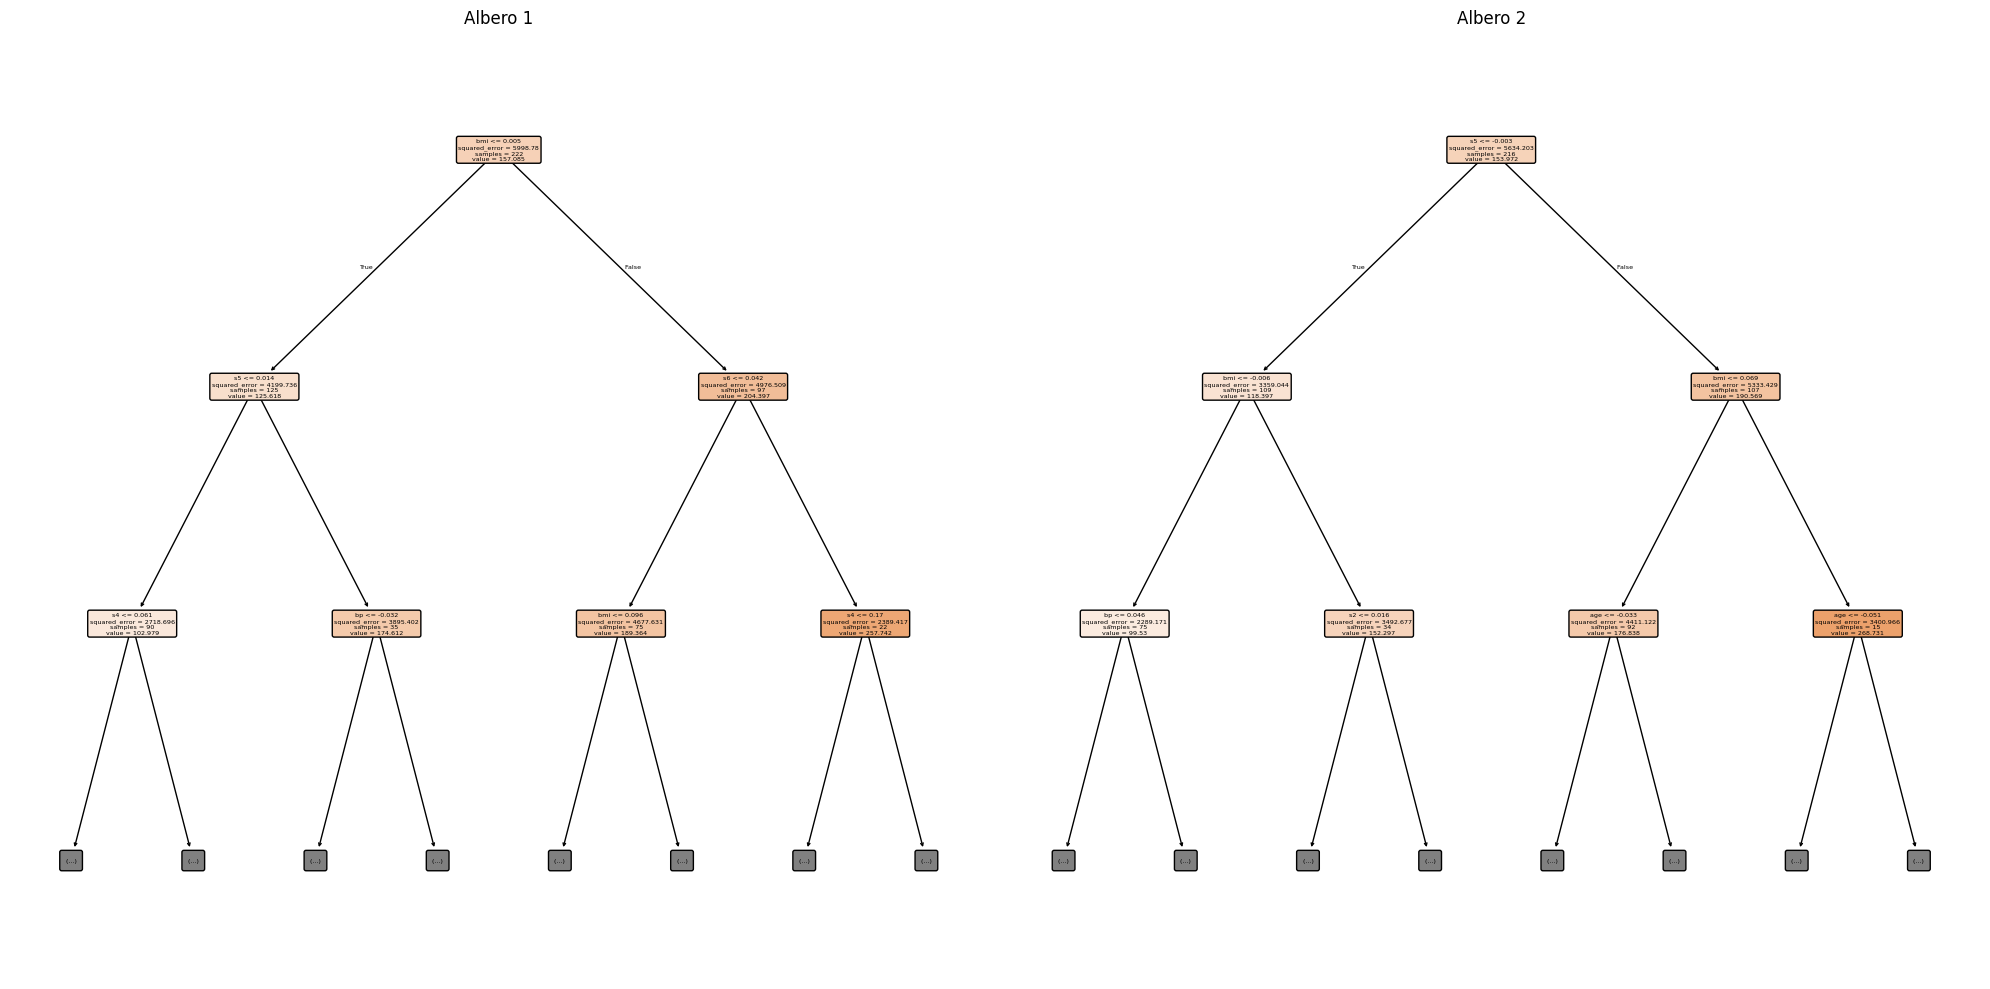

In [13]:
n_trees = 2

plt.figure(figsize=(20, 10))

for i in range(n_trees):
    plt.subplot(1, n_trees, i + 1)
    plot_tree(
        model_best.estimators_[i],
        feature_names=features_best,
        filled=True,
        rounded=True,
        max_depth=2
    )
    plt.title(f"Albero {i+1}")

plt.tight_layout()
plt.show()